In [1]:
import sys
from pathlib import Path

# Add the parent directory to sys.path
parent_path = Path().resolve().parent
if str(parent_path) not in sys.path:
    sys.path.append(str(parent_path))

In [2]:
from pyhgf.model import Network
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import seaborn as sns
from jax import config
from models import sample_cardiac_hgf

config.update("jax_enable_x64", True)

plt.rcParams["figure.constrained_layout.use"] = True

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [3]:
# load and filter the data -------------------------------------------------------------
hrd_path = Path.cwd().parent.parent / "data" / "hrd.csv"
main_df = pd.read_csv(hrd_path, index_col=0, low_memory=False)

In [41]:
hrd_df = main_df[((main_df.cohort == "vmp1") & (main_df.task == "hrd-session1"))]
hrd_df = hrd_df[hrd_df.participant_id.isin(hrd_df.participant_id.unique()[137:138])]

In [42]:
# extract variables for the model ------------------------------------------------------
n = hrd_df.participant_id.nunique()

heart_rate = [
    hrd_df[
        (hrd_df.participant_id == sub) & (hrd_df.Modality == "Intero")
    ].listenBPM.to_numpy()
    for sub in hrd_df.participant_id.unique()
]
intero_tone_2 = [
    hrd_df[
        (hrd_df.participant_id == sub) & (hrd_df.Modality == "Intero")
    ].responseBPM.to_numpy()
    for sub in hrd_df.participant_id.unique()
]
intero_decision = [
    (
        hrd_df[
            (hrd_df.participant_id == sub) & (hrd_df.Modality == "Intero")
        ].Decision.to_numpy()
        == "More"
    ).astype(int)
    for sub in hrd_df.participant_id.unique()
]

extero_tone_1 = [
    hrd_df[
        (hrd_df.participant_id == sub) & (hrd_df.Modality == "Extero")
    ].listenBPM.to_numpy()
    for sub in hrd_df.participant_id.unique()
]
extero_tone_2 = [
    hrd_df[
        (hrd_df.participant_id == sub) & (hrd_df.Modality == "Extero")
    ].responseBPM.to_numpy()
    for sub in hrd_df.participant_id.unique()
]
extero_decision = [
    (
        hrd_df[
            (hrd_df.participant_id == sub) & (hrd_df.Modality == "Extero")
        ].Decision.to_numpy()
        == "More"
    ).astype(int)
    for sub in hrd_df.participant_id.unique()
]

cotangent = np.ones(len(heart_rate) + len(extero_tone_1))

In [43]:
input_data_extero = [
    np.array([tone_1, tone2]).T for tone_1, tone2 in zip(extero_tone_1, extero_tone_2)
]
input_data_intero = [
    np.array([hr, tone2]).T for hr, tone2 in zip(heart_rate, intero_tone_2)
]

## The cardiac hierarchical Gaussian filer

In [44]:
idata, model = sample_cardiac_hgf(
    input_data_extero=input_data_extero,
    input_data_intero=input_data_intero,
    extero_decision=extero_decision,
    intero_decision=intero_decision,
    n=n,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [log_interoceptive_precision, log_exteroceptive_precision, interoceptive_tonic_volatility, exteroceptive_tonic_volatility, exteroceptive_mean, interoceptive_mean]
/home/nicolas/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/home/nicolas/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 26 seconds.
There were 13 divergences after tuning. Increase `target_accept` or reparameterize.


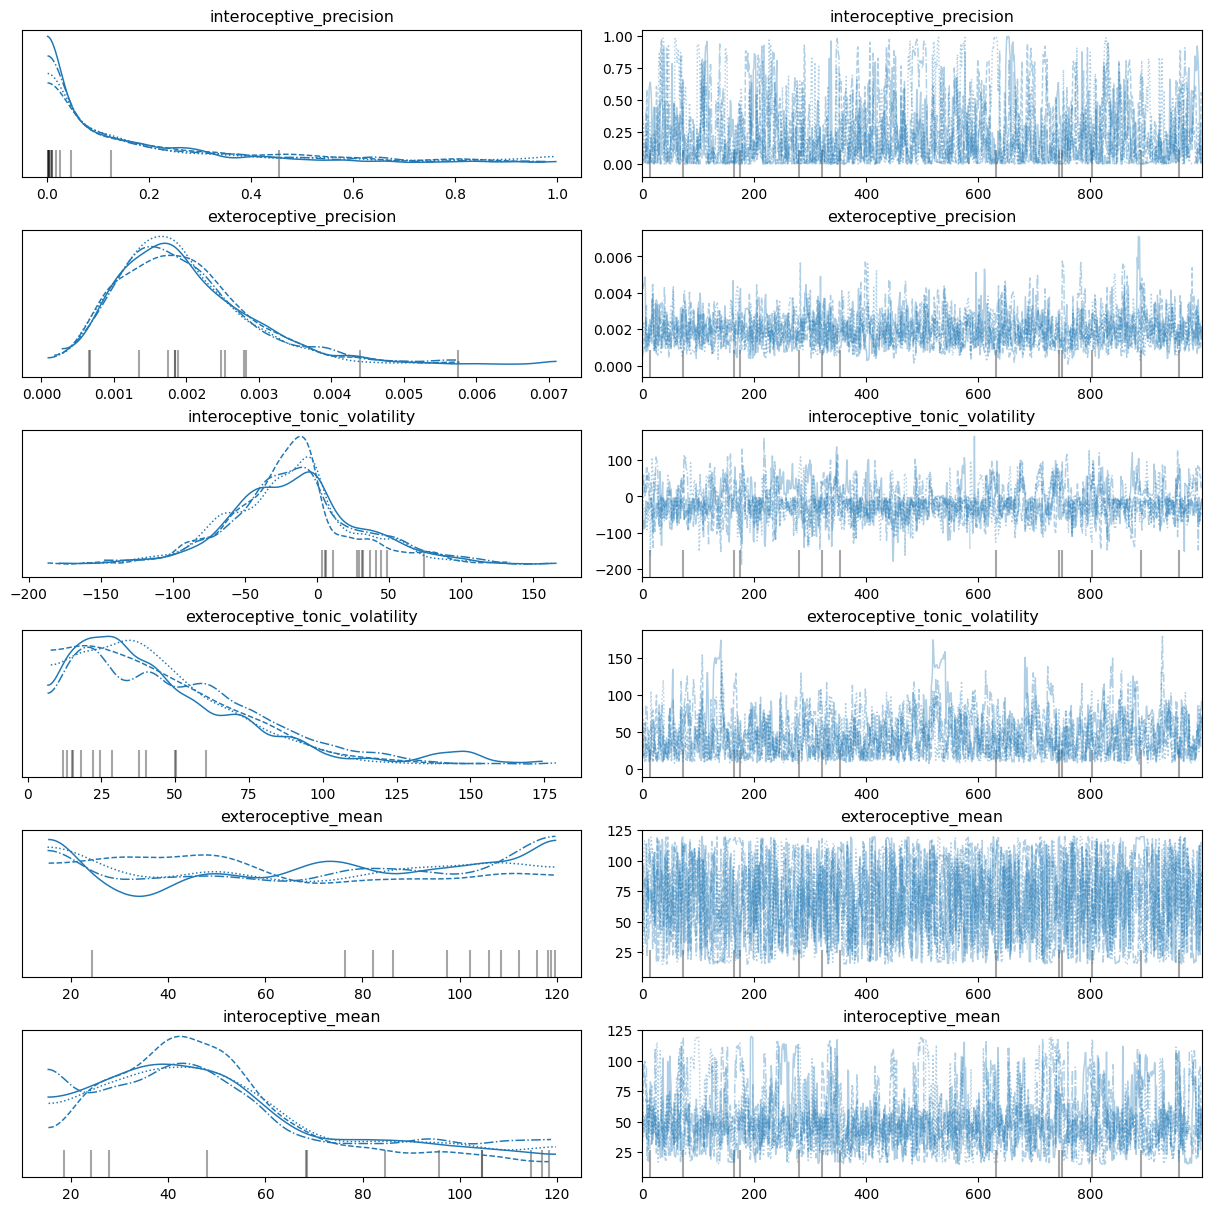

In [45]:
az.plot_trace(
    idata,
    var_names=[
        "interoceptive_precision",
        "exteroceptive_precision",
        "interoceptive_tonic_volatility",
        "exteroceptive_tonic_volatility",
        "exteroceptive_mean",
        "interoceptive_mean",
    ],
);

## Interoception

In [46]:
subj_idx = 0

In [47]:
interoceptive_precision = az.summary(idata, var_names=["interoceptive_precision"])[
    "mean"
].to_numpy()[subj_idx]
interoceptive_mean = az.summary(idata, var_names=["interoceptive_mean"])[
    "mean"
].to_numpy()[subj_idx]
interoceptive_tonic_volatility = az.summary(
    idata, var_names=["interoceptive_tonic_volatility"]
)["mean"].to_numpy()[subj_idx]

In [48]:
intero_network = (
    Network(update_type="unbounded")
    .add_nodes(
        precision=interoceptive_precision, expected_precision=interoceptive_precision
    )
    .add_nodes(
        value_children=0,
        mean=interoceptive_mean,
        tonic_volatility=interoceptive_tonic_volatility,
    )
).input_data(input_data=heart_rate[subj_idx])

In [49]:
exteroceptive_precision = az.summary(idata, var_names=["exteroceptive_precision"])[
    "mean"
].to_numpy()[subj_idx]
exteroceptive_mean = az.summary(idata, var_names=["exteroceptive_mean"])[
    "mean"
].to_numpy()[subj_idx]
exteroceptive_tonic_volatility = az.summary(
    idata, var_names=["exteroceptive_tonic_volatility"]
)["mean"].to_numpy()[subj_idx]

In [50]:
extero_network = (
    Network(update_type="unbounded")
    .add_nodes(
        precision=exteroceptive_precision, expected_precision=exteroceptive_precision
    )
    .add_nodes(
        value_children=0,
        mean=exteroceptive_mean,
        tonic_volatility=exteroceptive_tonic_volatility,
    )
).input_data(input_data=intero_tone_2[subj_idx])

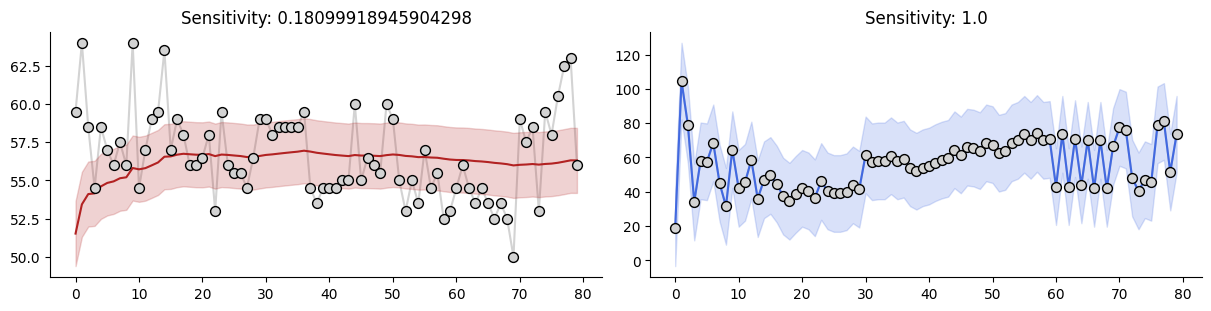

In [56]:
_, axs = plt.subplots(figsize=(12, 3), ncols=2)

# Intero -------------------------
axs[0].scatter(
    np.arange(0, len(heart_rate[subj_idx])),
    heart_rate[subj_idx],
    s=50,
    color="lightgrey",
    edgecolors="k",
)
axs[0].plot(
    np.arange(0, len(heart_rate[subj_idx])),
    heart_rate[subj_idx],
    color="lightgrey",
    zorder=-1,
)

axs[0].plot(
    np.arange(0, len(heart_rate[subj_idx])),
    intero_network.node_trajectories[1]["mean"],
    color="firebricK",
    zorder=-1,
)
std = np.sqrt(1 / intero_network.node_trajectories[0]["precision"])
axs[0].fill_between(
    x=np.arange(0, len(heart_rate[subj_idx])),
    y2=intero_network.node_trajectories[1]["mean"] + std,
    y1=intero_network.node_trajectories[1]["mean"] - std,
    color="firebricK",
    zorder=-1,
    alpha=0.2,
)

sensitivity = intero_network.node_trajectories[0]["precision"][0] / (
    intero_network.node_trajectories[0]["precision"][0]
    + intero_network.node_trajectories[1]["expected_precision"][0]
)

axs[0].set(title=f"Sensitivity: {sensitivity}")

# Extero -------------------------
axs[1].scatter(
    np.arange(0, len(intero_tone_2[subj_idx])),
    intero_tone_2[subj_idx],
    s=50,
    color="lightgrey",
    edgecolors="k",
)
axs[1].plot(
    np.arange(0, len(intero_tone_2[subj_idx])),
    intero_tone_2[subj_idx],
    color="lightgrey",
    zorder=-1,
)

axs[1].plot(
    np.arange(0, len(intero_tone_2[subj_idx])),
    extero_network.node_trajectories[1]["mean"],
    color="royalblue",
    zorder=-1,
)
std = np.sqrt(1 / extero_network.node_trajectories[0]["precision"])
axs[1].fill_between(
    x=np.arange(0, len(heart_rate[subj_idx])),
    y2=extero_network.node_trajectories[1]["mean"] + std,
    y1=extero_network.node_trajectories[1]["mean"] - std,
    color="royalblue",
    zorder=-1,
    alpha=0.2,
)

sensitivity = extero_network.node_trajectories[0]["precision"][0] / (
    extero_network.node_trajectories[0]["precision"][0]
    + extero_network.node_trajectories[1]["expected_precision"][0]
)

axs[1].set(title=f"Sensitivity: {sensitivity}")

sns.despine()